In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/kc_house_data.csv')



In [2]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [4]:
df_numeric = df.drop(['id', 'date'], axis=1)

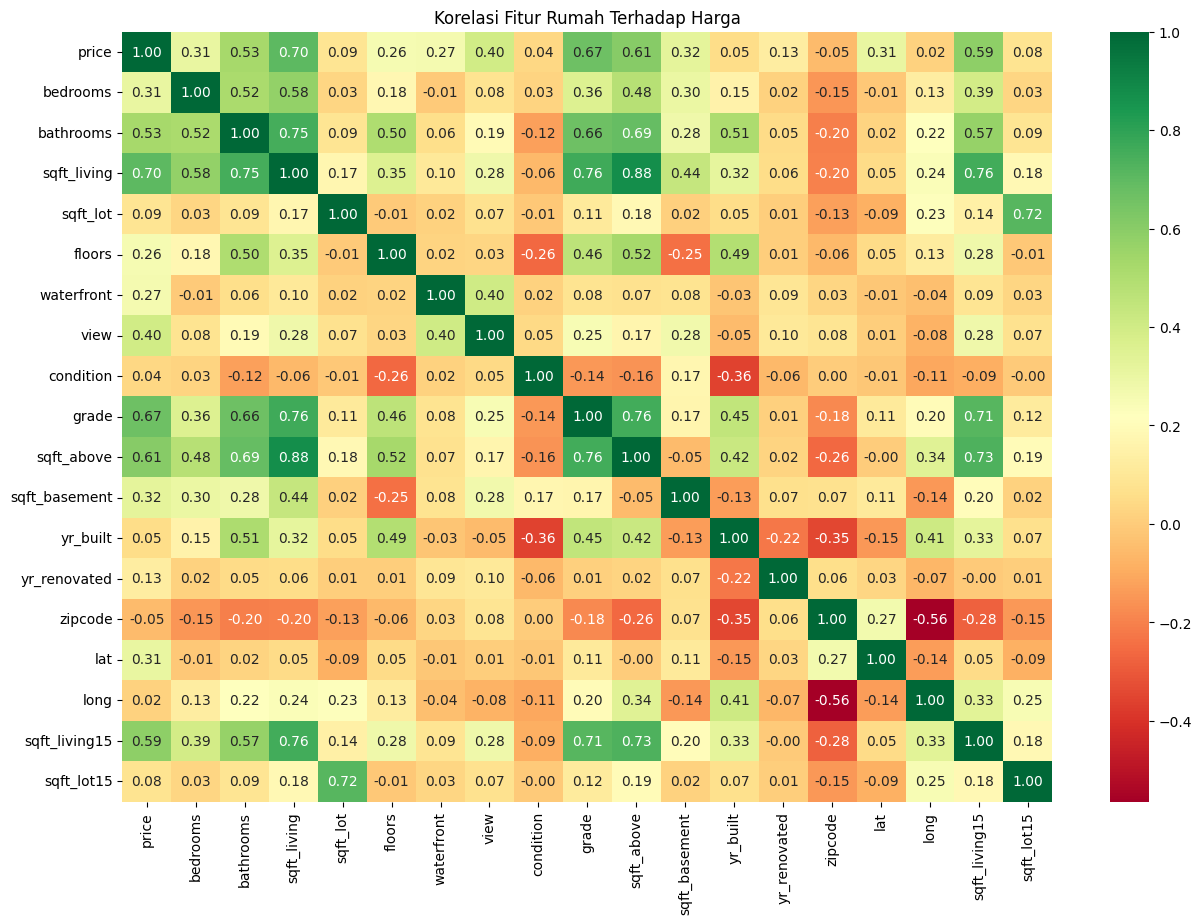

In [5]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_numeric.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Korelasi Fitur Rumah Terhadap Harga')
plt.show()

In [6]:
# Tambahkan 'long' dan 'zipcode' untuk informasi lokasi yang lebih tajam
# Tambahkan 'waterfront' karena rumah pinggir air harganya beda jauh
important_features = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 
                      'view', 'grade', 'sqft_above', 'lat', 'long', 
                      'sqft_living15', 'waterfront', 'zipcode']

In [7]:
df_final = df[important_features]

In [8]:
df_final.head()

,price,bedrooms,bathrooms,sqft_living,view,grade,sqft_above,lat,long,sqft_living15,waterfront,zipcode
0,221900.0,3,1.00,1180,0,7,1180,47.5112,-122.257,1340,0,98178
1,538000.0,3,2.25,2570,0,7,2170,47.7210,-122.319,1690,0,98125
2,180000.0,2,1.00,770,0,6,770,47.7379,-122.233,2720,0,98028
3,604000.0,4,3.00,1960,0,7,1050,47.5208,-122.393,1360,0,98136
4,510000.0,3,2.00,1680,0,8,1680,47.6168,-122.045,1800,0,98074


In [9]:
# Menghitung batas bawah dan batas atas untuk Price
Q1 = df_final['price'].quantile(0.25)
Q3 = df_final['price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Membuang data yang di luar batas (Outliers)
df_clean = df_final[(df_final['price'] >= lower_limit) & (df_final['price'] <= upper_limit)]

# Cek berapa banyak data yang tersisa
print(f"Data awal: {len(df_final)}")
print(f"Data setelah dibersihkan: {len(df_clean)}")

Data awal: 21613
Data setelah dibersihkan: 20467


In [10]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score

# Memisahkan X dan y
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# Membagi data Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Inisialisasi dan latih model
xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Prediksi dan cek skor
y_pred = xgb_model.predict(X_test)
accuracy = r2_score(y_test, y_pred)

print(f"Akurasi Model Saat Ini: {accuracy * 100:.2f}%")

Akurasi Model Saat Ini: 85.45%


In [12]:
from sklearn.model_selection import GridSearchCV

# Menyiapkan daftar parameter untuk dicoba
param_grid = {
    'n_estimators': [500, 700],
    'max_depth': [6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'colsample_bytree': [0.7, 0.8] # Teknik agar model tidak overfitting
}

grid_search = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42), 
                           param_grid=param_grid, 
                           cv=3, # Menggunakan 3-fold agar lebih cepat
                           scoring='r2', 
                           verbose=1)

grid_search.fit(X_train, y_train)

# Cek hasil terbaik
print(f"Best Score: {grid_search.best_score_}")
print(f"Best Params: {grid_search.best_params_}")

# Evaluasi pada data testing
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)
final_accuracy = r2_score(y_test, y_pred_final)

print(f"Akurasi Final: {final_accuracy * 100:.2f}%")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Score: 0.8624492483170895
Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 700}
Akurasi Final: 86.17%
